**Week 9: Visualization**

In [11]:
#Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#Load data
df = pd.read_csv("C:\ARCHIVOS\DOCUMENTS\Alvaro Universidad\M2 FIT\Practice\Sample - Superstore.csv",encoding = 'latin1')

<>:2: SyntaxWarning: invalid escape sequence '\A'
<>:2: SyntaxWarning: invalid escape sequence '\A'
C:\Users\maryl\AppData\Local\Temp\ipykernel_3720\1173986111.py:2: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv("C:\ARCHIVOS\DOCUMENTS\Alvaro Universidad\M2 FIT\Practice\Sample - Superstore.csv",encoding = 'latin1')


In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

**Exercise 1: Panel Dashboard**

C:\Users\maryl\AppData\Local\Temp\ipykernel_3720\1871929852.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot(data_by_region, labels = regions , patch_artist = True)


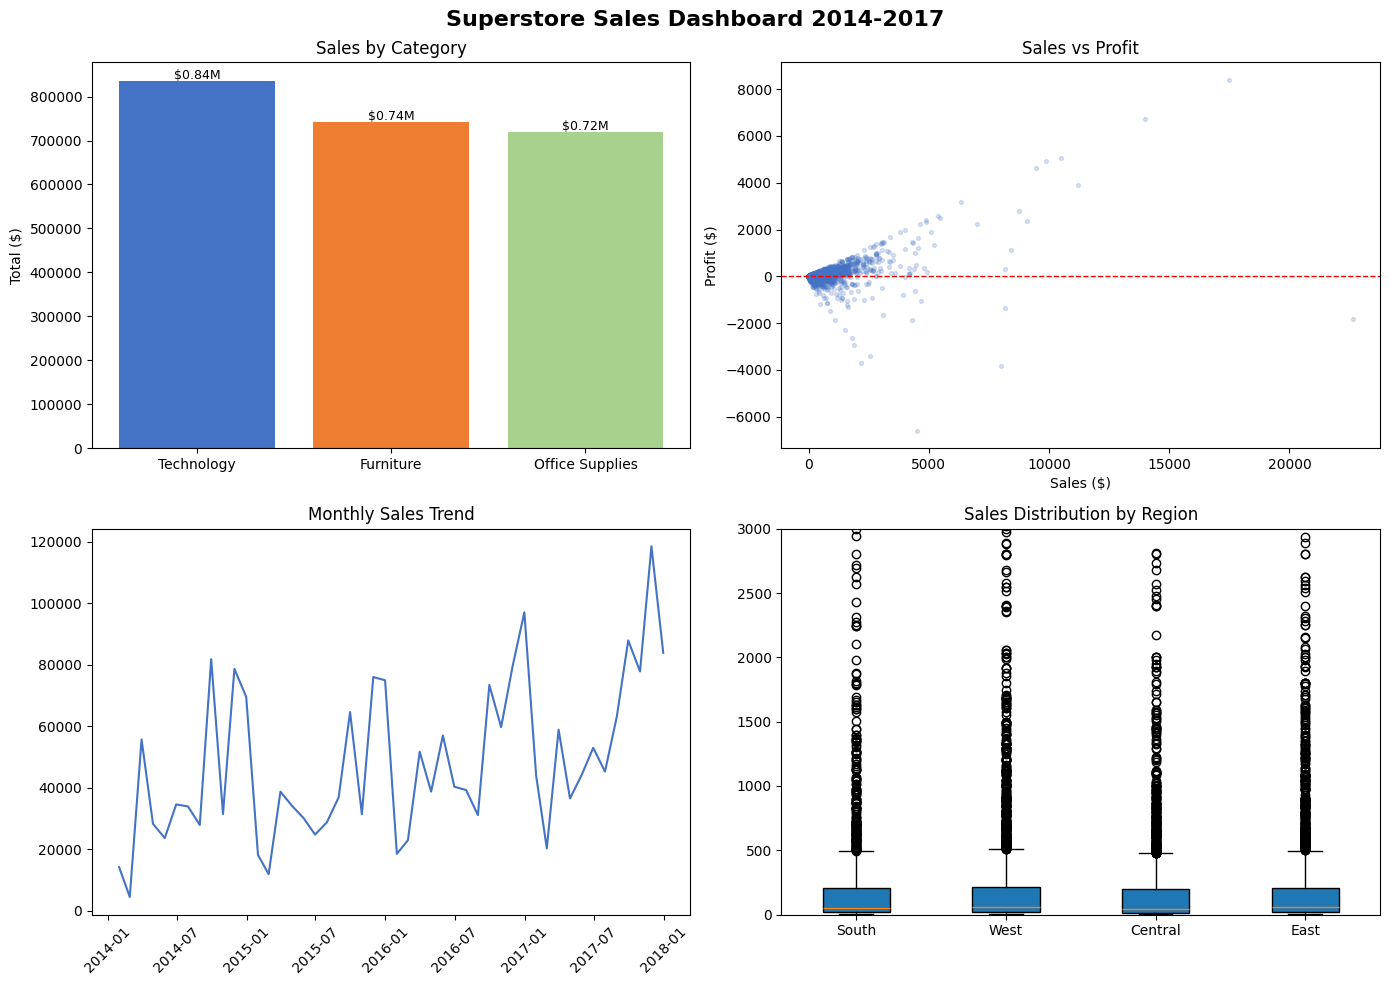

In [13]:
fig, axes = plt.subplots(2,2, figsize = (14,10))
fig.suptitle('Superstore Sales Dashboard 2014-2017',fontsize = 16, fontweight ='bold')

#Panel 1: Sales by category (Bar)
cat = df.groupby('Category')['Sales'].sum().sort_values(ascending = False)
axes[0,0].bar(cat.index,cat.values,color=['#4472C4','#ED7D31','#A9D18E'])
axes[0,0].set_title('Sales by Category')
axes[0,0].set_ylabel('Total ($)')
for i, v in enumerate(cat.values):
    axes[0,0].text(i,v+5000,f'${v/1e6:.2f}M',ha='center',fontsize = 9)

#Panel 2: Sales vs Profit (Scatter)
axes[0,1].scatter(df['Sales'],df['Profit'],alpha = 0.2, s=8, c='#4472C4')
axes[0,1].set_title('Sales vs Profit')
axes[0,1].axhline(0,color = 'red',linestyle = '--', linewidth= 1)
axes[0,1].set_xlabel('Sales ($)') 
axes[0,1].set_ylabel('Profit ($)')

#Panel 3: Monthly Trend
monthly = df.set_index('Order Date')['Sales'].resample('ME').sum()
axes[1,0].plot(monthly.index, monthly.values, color ='#4472C4',linewidth = 1.5)
axes[1,0].set_title('Monthly Sales Trend')
axes[1,0].tick_params(axis = 'x', rotation = 45)

#Panel 4: Box Plot by Region
regions = df['Region'].unique()
data_by_region = [df[df['Region']==r]['Sales'].values for r in regions]
axes[1,1].boxplot(data_by_region, labels = regions , patch_artist = True)
axes[1,1].set_title('Sales Distribution by Region')
axes[1,1].set_ylim(0,3000)

plt.tight_layout()
plt.savefig('dashboard.png', dpi = 150, bbox_inches = 'tight')
plt.show()